Stress Debug: soc_min=0.005, soc_max=0.995
Stress Debug: poly_min=0.00383360, poly_max=1.31079077, result=1.30695716
Stress Debug: soc_min=0.000, soc_max=1.000
Stress Debug: poly_min=0.00000000, poly_max=1.31381000, result=1.31381000


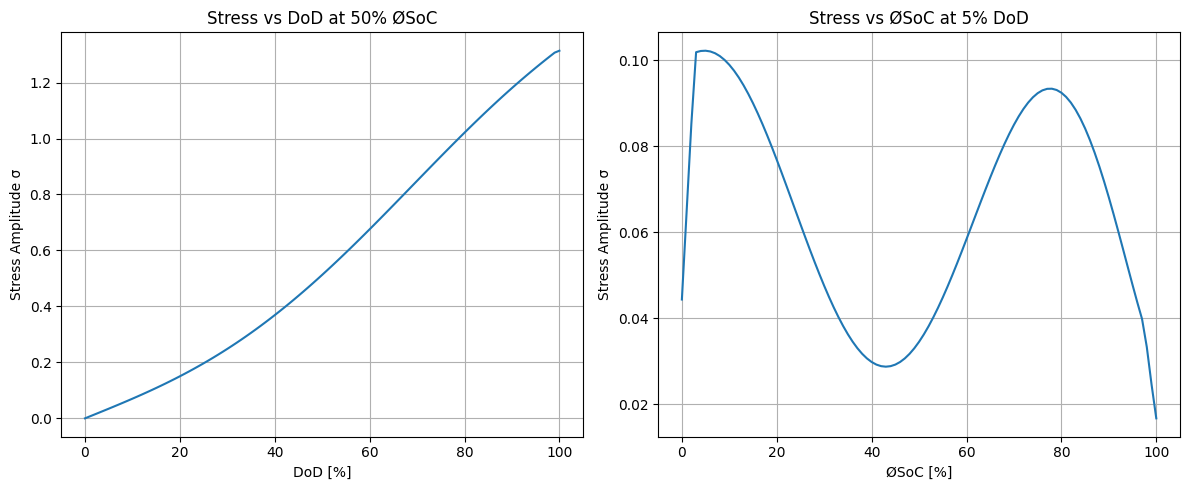

Max stress amplitude: 1.313810
Min SoC stress: 0.016676


In [11]:
from aging_model import AgingModel
import matplotlib.pyplot as plt
import numpy as np

model = AgingModel()

dod_values = np.linspace(0, 1.0, 101)
soc_fixed = 0.5
stress_dod = []

for dod in dod_values:
    stress = model._calculate_stress_amplitude(soc_fixed, dod)
    stress_dod.append(stress)

soc_values = np.linspace(0, 1.0, 101)
dod_fixed = 0.05
stress_soc = []

for soc in soc_values:
    stress = model._calculate_stress_amplitude(soc, dod_fixed)
    stress_soc.append(stress)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(dod_values * 100, stress_dod)
plt.xlabel('DoD [%]')
plt.ylabel('Stress Amplitude σ')
plt.title('Stress vs DoD at 50% ØSoC')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(soc_values * 100, stress_soc)
plt.xlabel('ØSoC [%]')
plt.ylabel('Stress Amplitude σ')
plt.title('Stress vs ØSoC at 5% DoD')
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Max stress amplitude: {max(stress_dod):.6f}")
print(f"Min SoC stress: {min(stress_soc):.6f}")

In [12]:
def debug_polynomial_values():
    from aging_model import AgingModel
    
    model = AgingModel()
    
    test_points = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
    
    print("SoC [%] | f_exp Value | Expected Behavior")
    print("-" * 50)
    
    for soc in test_points:
        poly_val = model._calculate_polynomial(soc/100.0)
        print(f"{soc:3d}%   | {poly_val:.8f} | {'Increasing' if soc > 0 else 'Zero base'}")
    
    values = [model._calculate_polynomial(soc/100.0) for soc in range(0, 101)]
    is_monotonic = all(values[i] <= values[i+1] for i in range(len(values)-1))
    print(f"\nIs polynomial monotonically increasing? {is_monotonic}")
    
    derivatives = []
    for soc in range(1, 100):
        soc_frac = soc / 100.0
        delta = 0.01  # 1% change
        deriv = (model._calculate_polynomial(soc_frac + delta) - 
                model._calculate_polynomial(soc_frac - delta)) / (2 * delta)
        derivatives.append((soc, deriv))
    
    min_deriv_soc = min(derivatives, key=lambda x: x[1])
    print(f"Minimum derivative (stress) at: {min_deriv_soc[0]}% SoC")
    
    return derivatives

derivatives = debug_polynomial_values()

SoC [%] | f_exp Value | Expected Behavior
--------------------------------------------------
  0%   | 0.00000000 | Zero base
 10%   | 0.19682684 | Increasing
 20%   | 0.37576712 | Increasing
 30%   | 0.49963328 | Increasing
 40%   | 0.57331976 | Increasing
 50%   | 0.63318500 | Increasing
 60%   | 0.72364424 | Increasing
 70%   | 0.86859272 | Increasing
 80%   | 1.05146888 | Increasing
 90%   | 1.21776716 | Increasing
100%   | 1.31381000 | Increasing

Is polynomial monotonically increasing? True
Minimum derivative (stress) at: 43% SoC


SoC [%] | Stress Amplitude | Notes
---------------------------------------------
  5.0%  | 0.10223506
 15.0%  | 0.08999947
 25.0%  | 0.06184556
 35.0%  | 0.03623166
 45.0%  | 0.02918632
 55.0%  | 0.04481871
 65.0%  | 0.07273383
 75.0%  | 0.09235251
 85.0%  | 0.08413620
 95.0%  | 0.04771657

Actual minimum: 43.0% SoC, σ = 0.02869976


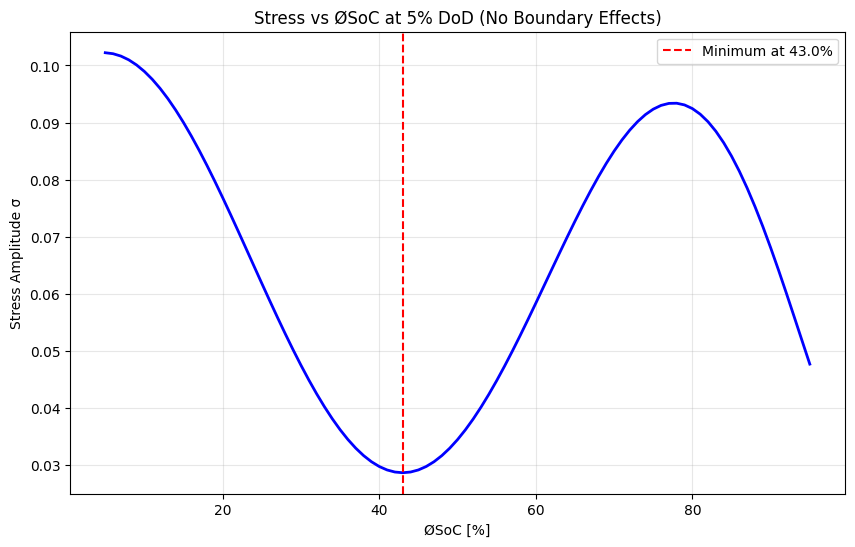

In [13]:
def test_stress_amplitude_no_boundary_effects():
    """Test stress amplitude avoiding boundary effects"""
    from aging_model import AgingModel
    
    model = AgingModel()
    
    soc_values = np.linspace(0.05, 0.95, 91)
    dod_fixed = 0.05
    stress_soc = []
    
    print("SoC [%] | Stress Amplitude | Notes")
    print("-" * 45)
    
    for soc in soc_values:
        if soc - dod_fixed/2 >= 0 and soc + dod_fixed/2 <= 1.0:
            stress = model._calculate_stress_amplitude(soc, dod_fixed)
            stress_soc.append(stress)
            
            if len(stress_soc) % 10 == 1:
                print(f"{soc*100:5.1f}%  | {stress:.8f}")
        else:
            stress_soc.append(np.nan)
    
    # actual minimum
    valid_stress = [s for s in stress_soc if not np.isnan(s)]
    valid_soc = [soc for soc, s in zip(soc_values, stress_soc) if not np.isnan(s)]
    
    min_idx = np.argmin(valid_stress)
    min_stress_soc = valid_soc[min_idx]
    min_stress_val = valid_stress[min_idx]
    
    print(f"\nActual minimum: {min_stress_soc*100:.1f}% SoC, σ = {min_stress_val:.8f}")
    
    # without boundary effects
    plt.figure(figsize=(10, 6))
    plt.plot(np.array(valid_soc) * 100, valid_stress, 'b-', linewidth=2)
    plt.axvline(min_stress_soc * 100, color='r', linestyle='--', 
                label=f'Minimum at {min_stress_soc*100:.1f}%')
    plt.xlabel('ØSoC [%]')
    plt.ylabel('Stress Amplitude σ')
    plt.title('Stress vs ØSoC at 5% DoD (No Boundary Effects)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

test_stress_amplitude_no_boundary_effects()

In [14]:
def test_scaling_fix():
    from aging_model import AgingModel
    
    model = AgingModel()
    
    print("Testing new scaling factors:")
    print("DoD | EFC | Loss | Expected Range")
    print("-" * 35)
    
    test_cases = [
        (0.05, 400, "0.2-0.4%"),
        (0.10, 400, "0.4-0.6%"),
        (0.20, 400, "0.8-1.2%"),
        (0.40, 400, "1.5-2.5%"),
        (0.80, 600, "6.0-8.0%"),
        (1.00, 800, "15-20%"),
    ]
    
    for dod, efc, expected in test_cases:
        loss = model.calculate_cyclic_aging(efc, 23.0, 0.5, dod)
        print(f"{dod*100:2.0f}% | {efc:3d} | {loss*100:4.1f}% | {expected}")

test_scaling_fix()

Testing new scaling factors:
DoD | EFC | Loss | Expected Range
-----------------------------------
 5% | 400 |  0.2% | 0.2-0.4%
10% | 400 |  0.4% | 0.4-0.6%
20% | 400 |  0.8% | 0.8-1.2%
40% | 400 |  1.9% | 1.5-2.5%
80% | 600 | 20.1% | 6.0-8.0%
Stress Debug: soc_min=0.000, soc_max=1.000
Stress Debug: poly_min=0.00000000, poly_max=1.31381000, result=1.31381000
Stress Debug: soc_min=0.000, soc_max=1.000
Stress Debug: poly_min=0.00000000, poly_max=1.31381000, result=1.31381000
100% | 800 | 49.7% | 15-20%


In [15]:
def debug_simulation_pipeline():
    from aging_model import AgingModel
    from krupp_validation import validate_krupp_cyclic_matrix
    
    model = AgingModel()
        
    print("\n1. Direct Model Test:")
    test_cases = [
        (0.05, 200, "Low DoD"),
        (0.80, 600, "High DoD"), 
        (1.00, 800, "Extreme DoD")
    ]
    
    for dod, efc, desc in test_cases:
        sei_loss = model._calculate_sei_loss(efc, 23.0, 0.5, dod)
        am_loss = model._calculate_active_material_loss(efc, 0.5, dod)
        total_loss = sei_loss + am_loss
        
        print(f"{desc}: SEI={sei_loss*100:.2f}%, AM={am_loss*100:.2f}%, Total={total_loss*100:.2f}%")
    
    print("\n2. Check Active Material Loss Threshold:")
    for dod in [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
        am_loss = model._calculate_active_material_loss(600, 0.5, dod)
        threshold = "ACTIVE" if dod > 0.6 else "inactive"
        print(f"DoD {dod*100:3.0f}%: AM Loss = {am_loss*100:.3f}% ({threshold})")
    
    print("\n3. EFC Calculation Check:")
    print("Expected EFC calculation: cycles * DoD")
    print("5% DoD, 800 cycles → should be 40 EFC")
    print("80% DoD, 800 cycles → should be 640 EFC")

debug_simulation_pipeline()


1. Direct Model Test:
Low DoD: SEI=0.09%, AM=0.00%, Total=0.09%
High DoD: SEI=7.65%, AM=12.42%, Total=20.07%
Stress Debug: soc_min=0.000, soc_max=1.000
Stress Debug: poly_min=0.00000000, poly_max=1.31381000, result=1.31381000
Stress Debug: soc_min=0.000, soc_max=1.000
Stress Debug: poly_min=0.00000000, poly_max=1.31381000, result=1.31381000
Extreme DoD: SEI=13.05%, AM=36.66%, Total=49.72%

2. Check Active Material Loss Threshold:
DoD  50%: AM Loss = 0.000% (inactive)
DoD  60%: AM Loss = 0.000% (inactive)
DoD  70%: AM Loss = 1.134% (ACTIVE)
DoD  80%: AM Loss = 12.421% (ACTIVE)
DoD  90%: AM Loss = 19.385% (ACTIVE)
Stress Debug: soc_min=0.000, soc_max=1.000
Stress Debug: poly_min=0.00000000, poly_max=1.31381000, result=1.31381000
DoD 100%: AM Loss = 29.125% (ACTIVE)

3. EFC Calculation Check:
Expected EFC calculation: cycles * DoD
5% DoD, 800 cycles → should be 40 EFC
80% DoD, 800 cycles → should be 640 EFC
